In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm

from sklearn.cluster import KMeans, DBSCAN, AgglomerativeClustering
from sklearn.metrics import silhouette_score,silhouette_samples
from sklearn.preprocessing import MinMaxScaler

In [2]:
df = pd.read_csv('Datos/Transformados/df_model_dummies_cluster.csv')
print("Shape inicial:", df.shape)
df.columns

Shape inicial: (52150, 59)


Index(['lead_time', 'lenght_of_stay', 'adult_count', 'child_count',
       'available_units', 'completed_entry_forms_count', 'product_count',
       'reservation_net_value', 'total_adr', 'espera_dias', 'recurrence',
       'tmed', 'prec', 'sol', 'ratio_asistencia', 'bought_products',
       'returning_inhabitant', 'libere_community', 'asset_type_aparthotel',
       'asset_type_apartment', 'asset_type_hostel',
       'business_segment_Business Group',
       'business_segment_Business Individual',
       'business_segment_Leisure Group', 'business_segment_Leisure Individual',
       'business_segment_MICE Group', 'business_segment_MICE Individual',
       'business_segment_Mid Stay', 'business_segment_Travel Group',
       'business_segment_Travel Individual', 'rate_type_Flexible',
       'rate_type_Mid Stay', 'rate_type_Non Refundable',
       'origin_channel_manager', 'origin_direct_channel', 'origin_email',
       'origin_in_person', 'origin_telephone', 'provincia_ARABA/ALAVA',
     

Definir columnas para escalar

In [3]:
cols_num_cluster = [
    'lead_time', 'lenght_of_stay', 'adult_count', 'child_count',
    'available_units', 'completed_entry_forms_count', 'product_count',
    'reservation_net_value', 'total_adr', 'espera_dias',
    'recurrence', 'tmed', 'prec', 'sol', 'ratio_asistencia'
]

cols_bin_cluster = [
    'bought_products', 'returning_inhabitant', 'libere_community'
]

# Nos quedamos solo con las que EXISTAN en el df
cols_scale = [c for c in (cols_num_cluster + cols_bin_cluster) if c in df.columns]

df_clustering = df.copy()

print("Shape clustering (incluye dummies):", df_clustering.shape)
print("Nº columnas a escalar:", len(cols_scale))
print("Columnas a escalar:", cols_scale)

Shape clustering (incluye dummies): (52150, 59)
Nº columnas a escalar: 18
Columnas a escalar: ['lead_time', 'lenght_of_stay', 'adult_count', 'child_count', 'available_units', 'completed_entry_forms_count', 'product_count', 'reservation_net_value', 'total_adr', 'espera_dias', 'recurrence', 'tmed', 'prec', 'sol', 'ratio_asistencia', 'bought_products', 'returning_inhabitant', 'libere_community']


MinMaxScaler a numericas

In [4]:
scaler = MinMaxScaler()

df_scaled = df_clustering.copy()
df_scaled[cols_scale] = scaler.fit_transform(df_scaled[cols_scale])

print("Shape tras MinMaxScaler:", df_scaled.shape)

Shape tras MinMaxScaler: (52150, 59)


Dataframe final con componentes principales

In [5]:
# Matriz final para clustering (SIN PCA)
X = df_scaled.values
print("Shape X (sin PCA):", X.shape)


Shape X (sin PCA): (52150, 59)


### Clustering KMEANS (k 2..10)


KMeans silhouette: {2: 0.1293225801522279, 3: 0.19896958624414232, 4: 0.17875671845865593, 5: 0.14154952083710254, 6: 0.1327526115865128, 7: 0.13954236200954281, 8: 0.13546461074122754, 9: 0.13166028633454366, 10: 0.13342431766896493}
Best KMeans k: 3 sil: 0.19896958624414232


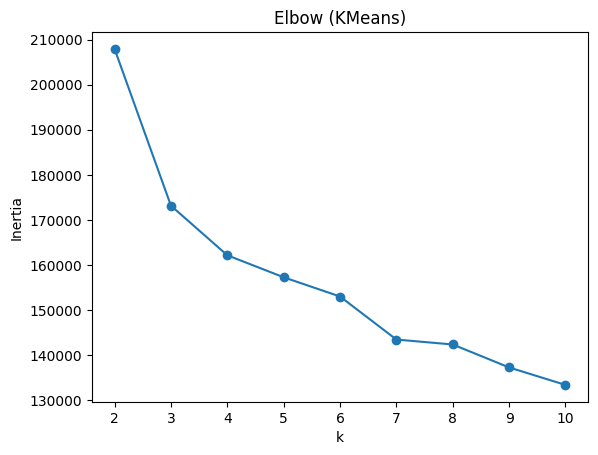

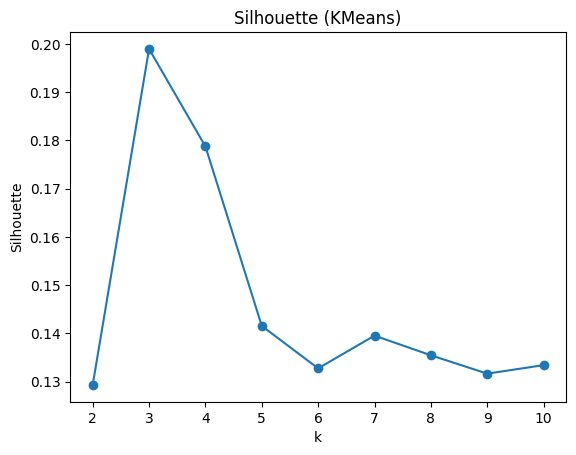

In [6]:
Ks = range(2, 11)
kmeans_sil = {}
kmeans_inertia = {}

for k in Ks:
    km = KMeans(n_clusters=k, random_state=42, n_init="auto")
    labels = km.fit_predict(X)
    kmeans_inertia[k] = km.inertia_
    kmeans_sil[k] = silhouette_score(X, labels)

print("KMeans silhouette:", kmeans_sil)
best_k = max(kmeans_sil, key=kmeans_sil.get)
print("Best KMeans k:", best_k, "sil:", kmeans_sil[best_k])

plt.figure()
plt.plot(list(kmeans_inertia.keys()), list(kmeans_inertia.values()), marker="o")
plt.xlabel("k")
plt.ylabel("Inertia")
plt.title("Elbow (KMeans)")
plt.show()

plt.figure()
plt.plot(list(kmeans_sil.keys()), list(kmeans_sil.values()), marker="o")
plt.xlabel("k")
plt.ylabel("Silhouette")
plt.title("Silhouette (KMeans)")
plt.show()

### Clustering JERÁRQUICO (Agglomerative) (k 2..10)


Agglomerative silhouette: {2: 0.14793334592938803, 3: 0.1835684344381099, 4: 0.19111114473949925, 5: 0.136141170559775, 6: 0.12822780062682376, 7: 0.13213937731070155, 8: 0.13505220556708936, 9: 0.13003151250630046, 10: 0.12775867304507305}
Best Agglomerative k: 4 sil: 0.19111114473949925


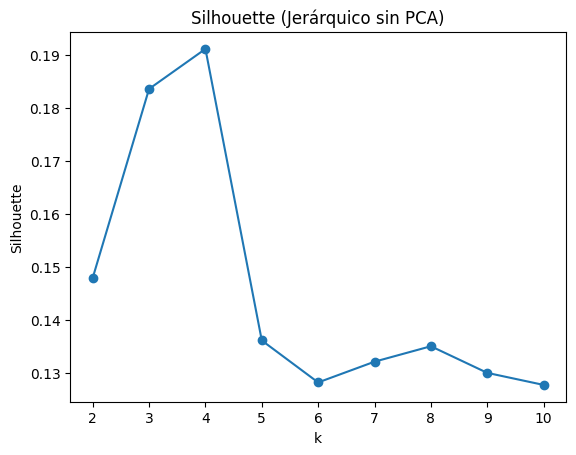

In [7]:
# Clustering jerárquico SIN muestras (dataset completo)
agg_sil = {}

for k in Ks:
    agg = AgglomerativeClustering(n_clusters=k, linkage="ward")
    labels = agg.fit_predict(X)
    agg_sil[k] = silhouette_score(X, labels)

print("Agglomerative silhouette:", agg_sil)
best_k_agg = max(agg_sil, key=agg_sil.get)
print("Best Agglomerative k:", best_k_agg, "sil:", agg_sil[best_k_agg])

plt.figure()
plt.plot(list(agg_sil.keys()), list(agg_sil.values()), marker="o")
plt.xlabel("k")
plt.ylabel("Silhouette")
plt.title("Silhouette (Jerárquico sin PCA)")
plt.show()


### Clustering DBSCAN (probamos varios eps/min_samples)


In [8]:
eps_list = [1.0, 1.5, 2.0, 2.5, 3.0]
min_samples_list = [5, 10, 20]

dbscan_results = []

for eps in eps_list:
    for ms in min_samples_list:
        db = DBSCAN(eps=eps, min_samples=ms)
        labels = db.fit_predict(X)

        # clusters válidos (excluye ruido -1)
        unique_labels = set(labels)
        n_noise = np.sum(labels == -1)
        n_clusters = len(unique_labels) - (1 if -1 in unique_labels else 0)

        sil = None
        if n_clusters >= 2:
            # silhouette SOLO sobre puntos que no son ruido
            mask = labels != -1
            sil = silhouette_score(X[mask], labels[mask])

        dbscan_results.append({
            "eps": eps,
            "min_samples": ms,
            "n_clusters": n_clusters,
            "n_noise": n_noise,
            "silhouette": sil
        })

# Ordenar: primero los que tienen silhouette (no None), luego por silhouette desc
dbscan_results_sorted = sorted(
    dbscan_results,
    key=lambda d: (-1 if d["silhouette"] is None else d["silhouette"]),
    reverse=True
)

print("\nTop DBSCAN configs (mejores silhouette):")
for r in dbscan_results_sorted[:10]:
    print(r)



Top DBSCAN configs (mejores silhouette):
{'eps': 1.0, 'min_samples': 20, 'n_clusters': 515, 'n_noise': np.int64(18966), 'silhouette': 0.5115365848808852}
{'eps': 1.0, 'min_samples': 10, 'n_clusters': 1028, 'n_noise': np.int64(11800), 'silhouette': 0.5028991846965855}
{'eps': 1.0, 'min_samples': 5, 'n_clusters': 1902, 'n_noise': np.int64(5976), 'silhouette': 0.5007536762918721}
{'eps': 2.0, 'min_samples': 20, 'n_clusters': 4, 'n_noise': np.int64(63), 'silhouette': 0.19247005317797156}
{'eps': 2.0, 'min_samples': 10, 'n_clusters': 4, 'n_noise': np.int64(29), 'silhouette': 0.19240461979425935}
{'eps': 2.0, 'min_samples': 5, 'n_clusters': 4, 'n_noise': np.int64(26), 'silhouette': 0.1923899874350015}
{'eps': 1.5, 'min_samples': 20, 'n_clusters': 4, 'n_noise': np.int64(629), 'silhouette': 0.18929951329778752}
{'eps': 1.5, 'min_samples': 10, 'n_clusters': 8, 'n_noise': np.int64(313), 'silhouette': 0.15114902546158168}
{'eps': 1.5, 'min_samples': 5, 'n_clusters': 11, 'n_noise': np.int64(200),

KMeans y Jerárquico coinciden en k=3 con el mejor silhouette (~0.209). 

Se selecciona KMeans por su menor coste computacional y facilidad de interpretación. 

DBSCAN genera cientos/miles de clusters y una proporción alta de ruido, por lo que se descarta para segmentación operativa

Generando gráficos con el dataset completo (52150 registros)...
Para k=2, el Silhouette Score promedio es: 0.1293


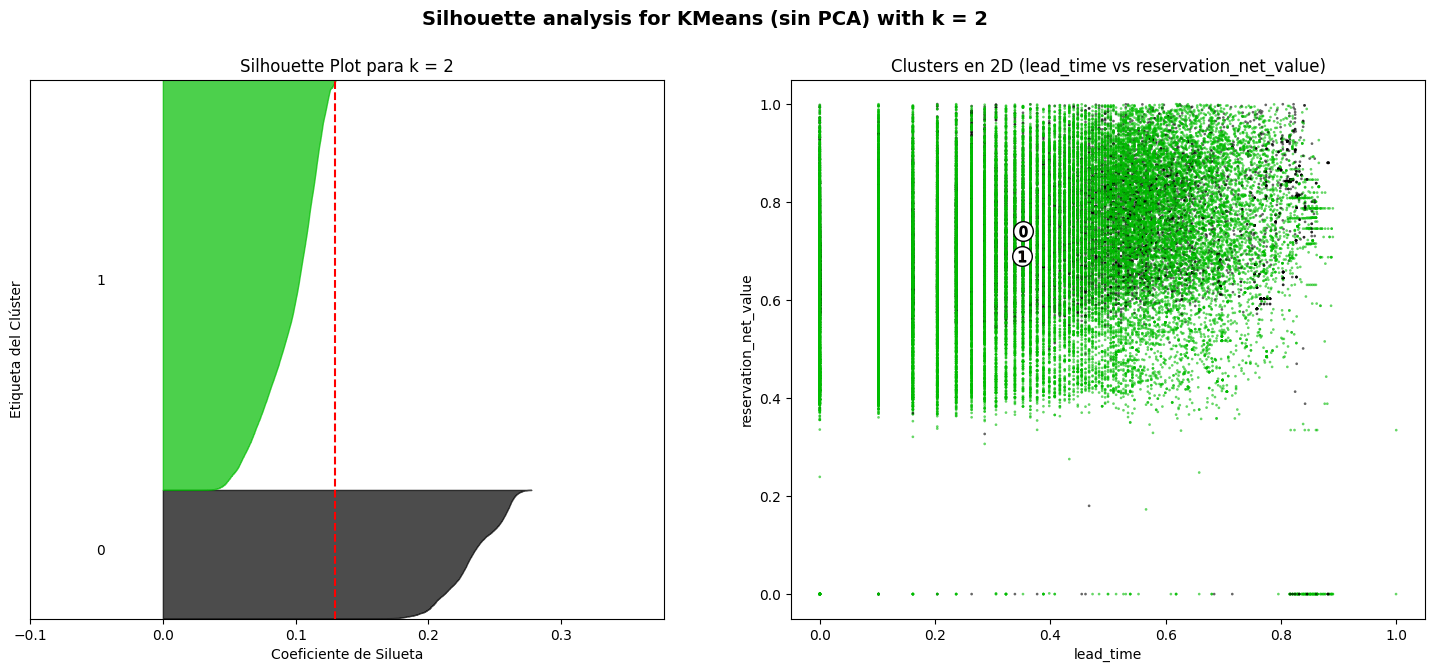

Para k=3, el Silhouette Score promedio es: 0.1990


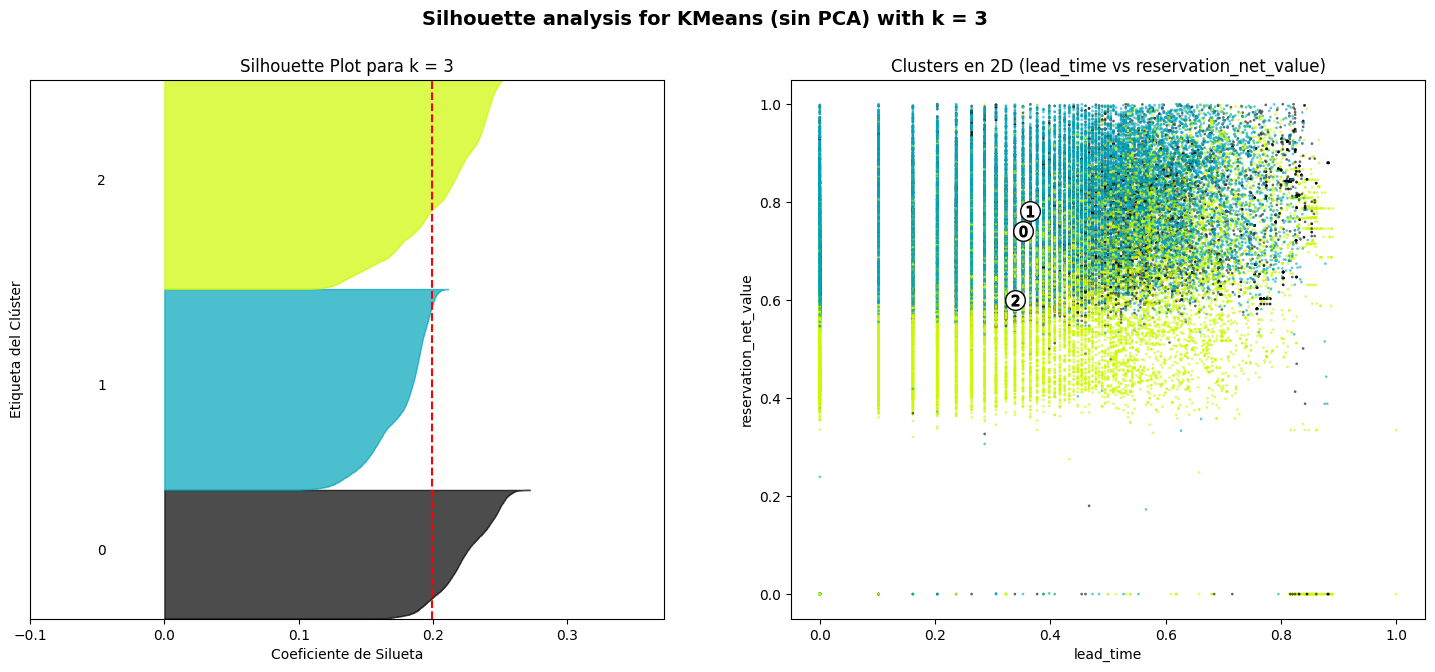

Para k=4, el Silhouette Score promedio es: 0.1788


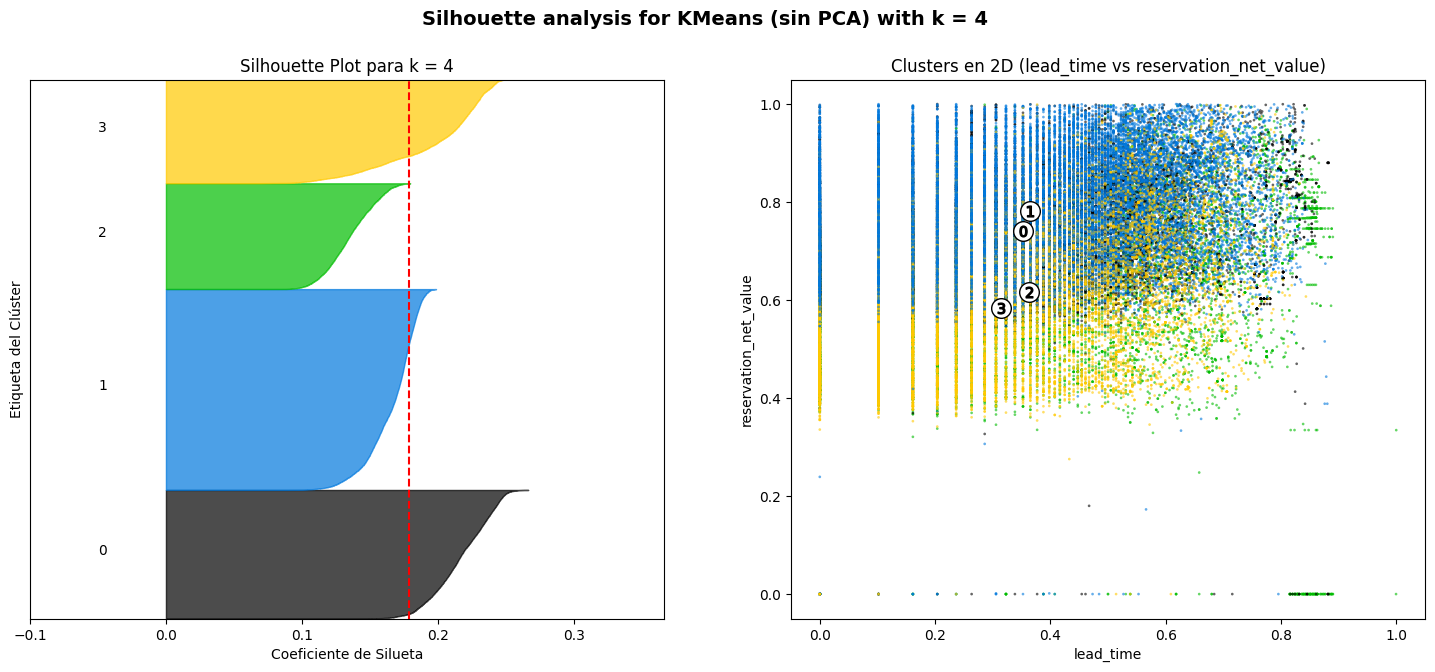

Para k=5, el Silhouette Score promedio es: 0.1415


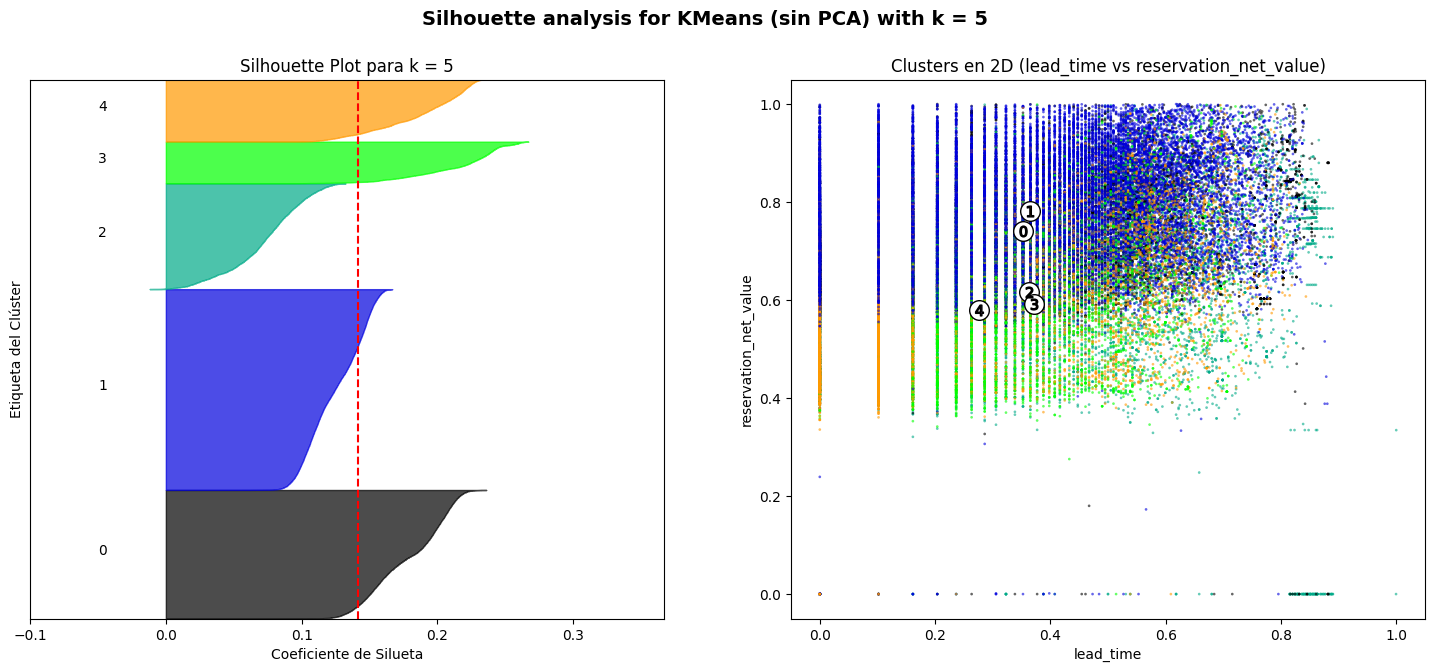

Para k=6, el Silhouette Score promedio es: 0.1328


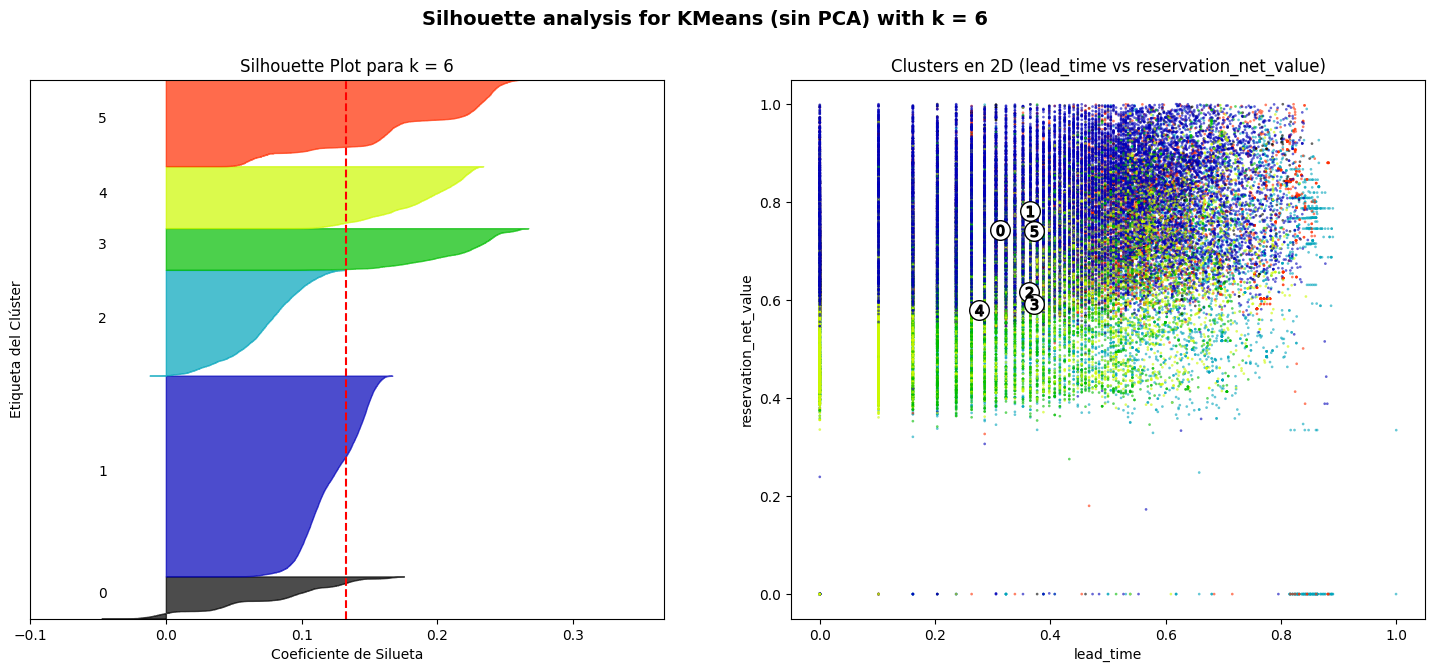

Para k=7, el Silhouette Score promedio es: 0.1395


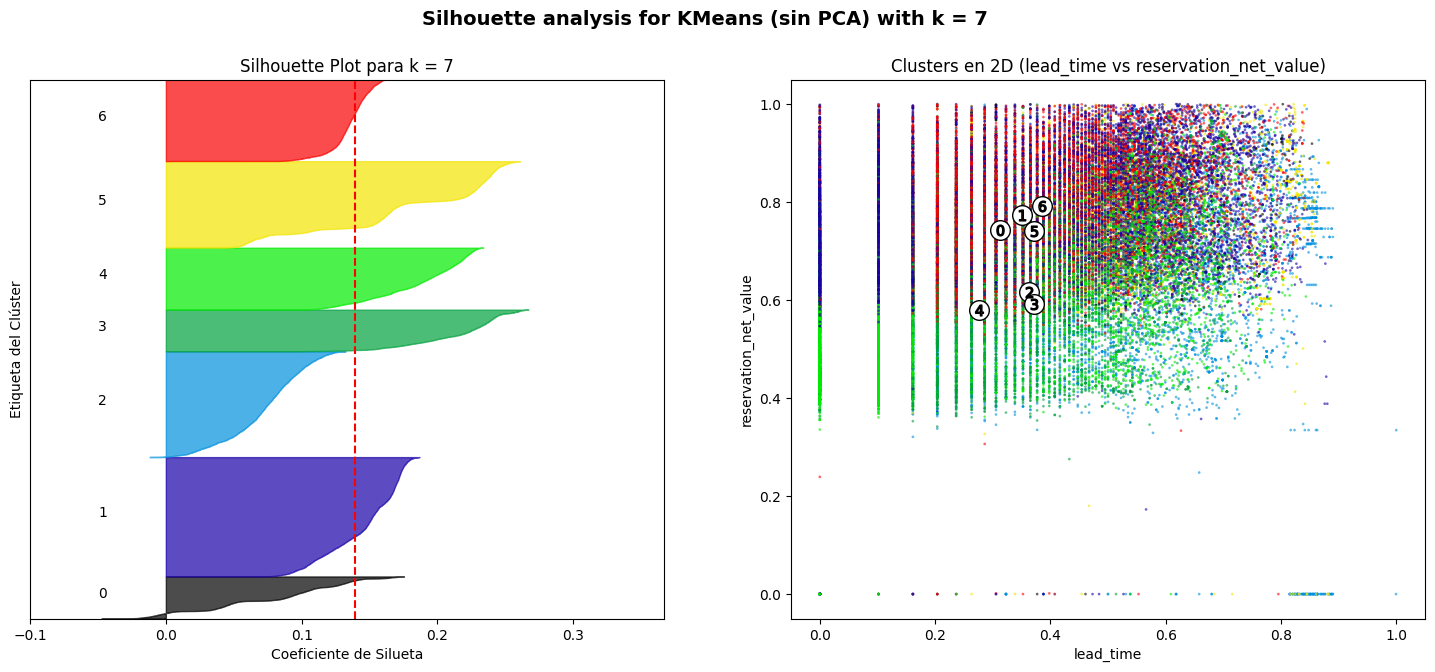

Para k=8, el Silhouette Score promedio es: 0.1355


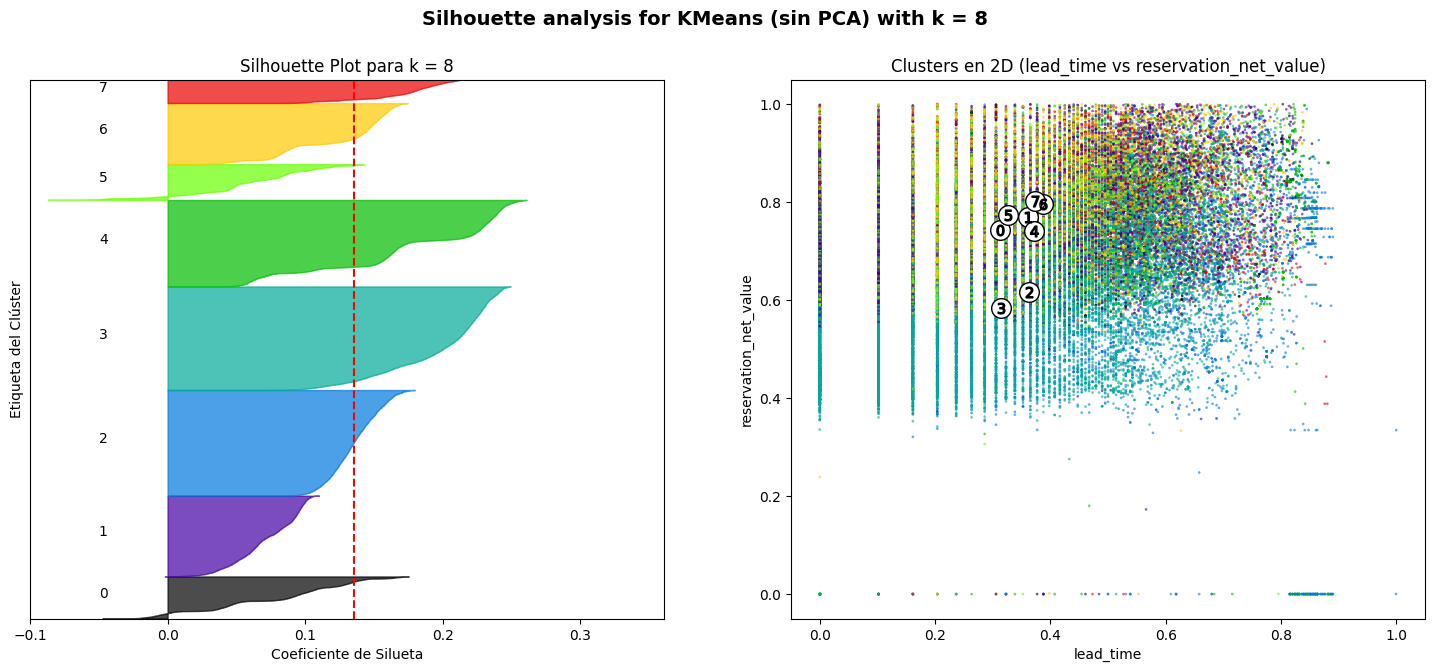

Para k=9, el Silhouette Score promedio es: 0.1317


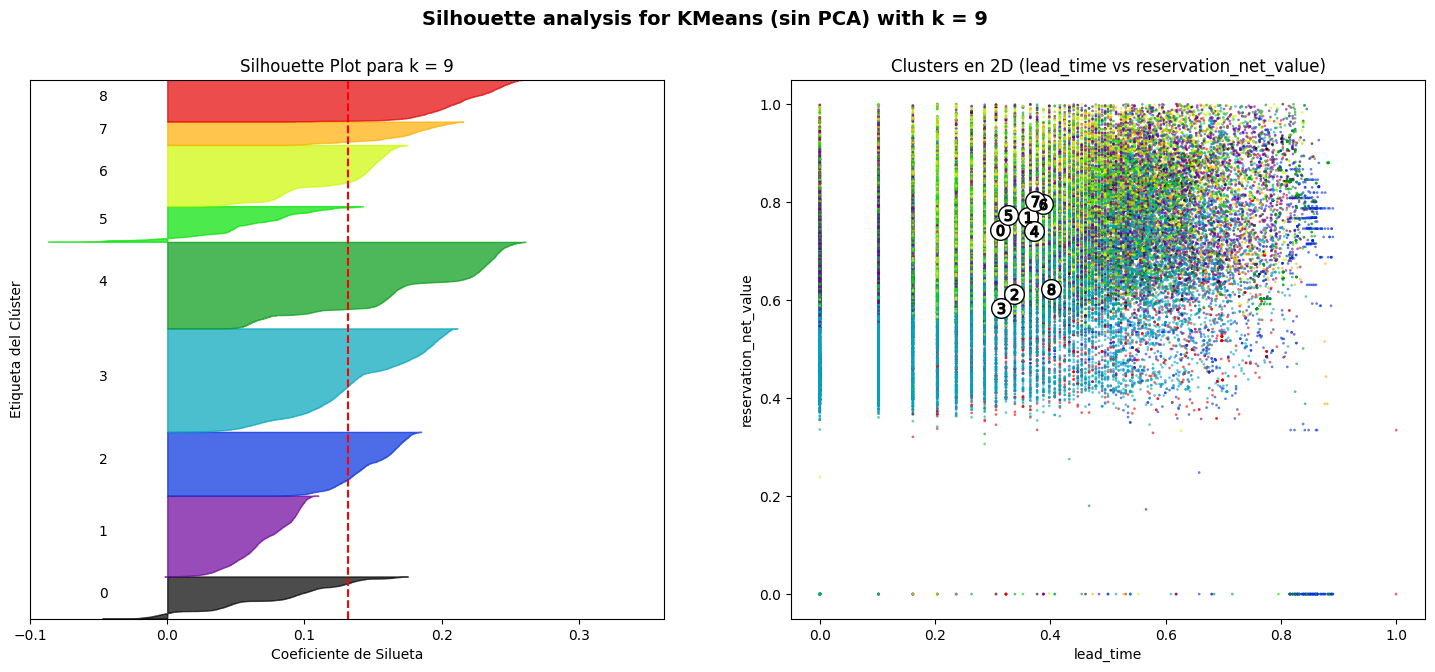

Para k=10, el Silhouette Score promedio es: 0.1334


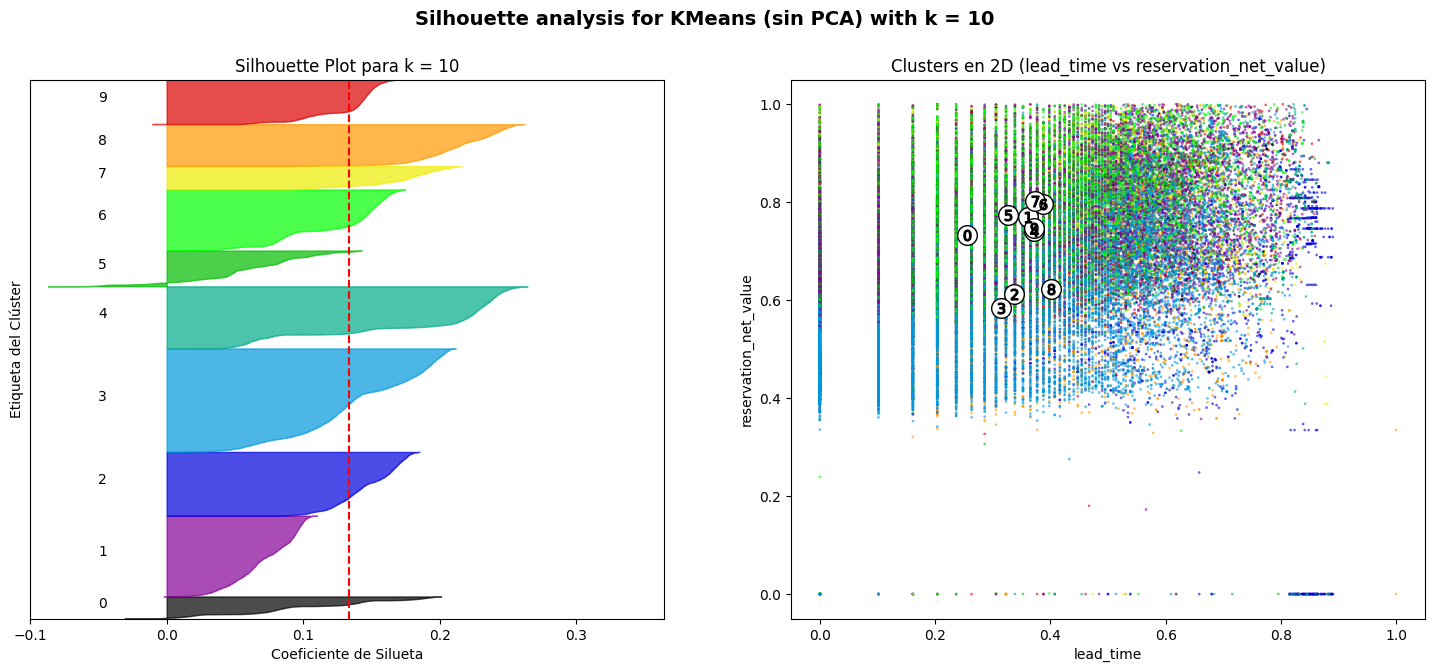

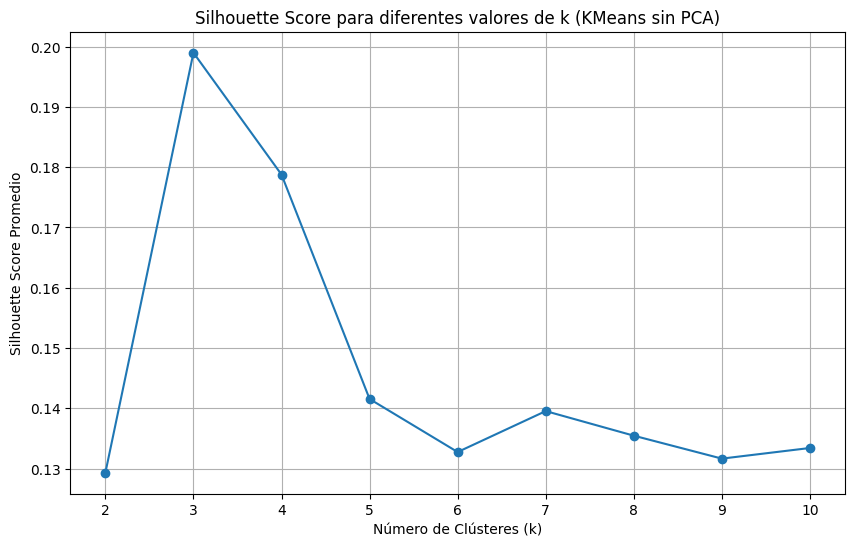

In [13]:
X = df_scaled.values

# Elegimos 2 variables REALES para el scatter
feat_x = 'lead_time'
feat_y = 'reservation_net_value'

# índices de esas variables dentro de df_scaled
ix = df_scaled.columns.get_loc(feat_x)
iy = df_scaled.columns.get_loc(feat_y)

X_2d = df_scaled[[feat_x, feat_y]].values

range_n_clusters = [2, 3, 4, 5, 6, 7, 8, 9, 10]
silhouette_scores = []

print(f"Generando gráficos con el dataset completo ({len(X)} registros)...")

for n_clusters in range_n_clusters:
    clusterer = KMeans(n_clusters=n_clusters, random_state=42, n_init="auto")
    cluster_labels = clusterer.fit_predict(X)

    # Silhouette con TODO el dataset
    silhouette_avg = silhouette_score(X, cluster_labels)
    silhouette_scores.append(silhouette_avg)
    print(f"Para k={n_clusters}, el Silhouette Score promedio es: {silhouette_avg:.4f}")

    # Silhouette por muestra → ahora por TODAS las muestras
    sample_silhouette_values = silhouette_samples(X, cluster_labels)

    fig, (ax1, ax2) = plt.subplots(1, 2)
    fig.set_size_inches(18, 7)

    # -----------------------
    # IZQUIERDA: Silhouette plot
    # -----------------------
    max_score = sample_silhouette_values.max()
    ax1.set_xlim([-0.1, max_score + 0.1])
    ax1.set_ylim([0, len(X) + (n_clusters + 1) * 10])

    y_lower = 10
    for i in range(n_clusters):
        ith_vals = sample_silhouette_values[cluster_labels == i]
        ith_vals.sort()

        size_i = ith_vals.shape[0]
        y_upper = y_lower + size_i

        color = cm.nipy_spectral(float(i) / n_clusters)
        ax1.fill_betweenx(
            np.arange(y_lower, y_upper),
            0,
            ith_vals,
            facecolor=color,
            edgecolor=color,
            alpha=0.7
        )
        ax1.text(-0.05, y_lower + 0.5 * size_i, str(i))
        y_lower = y_upper + 10

    ax1.axvline(x=silhouette_avg, color="red", linestyle="--")
    ax1.set_title(f"Silhouette Plot para k = {n_clusters}")
    ax1.set_xlabel("Coeficiente de Silueta")
    ax1.set_ylabel("Etiqueta del Clúster")
    ax1.set_yticks([])

    # -----------------------
    # DERECHA: scatter 2D
    # -----------------------
    colors = cm.nipy_spectral(cluster_labels.astype(float) / n_clusters)

    ax2.scatter(
        X_2d[:, 0], X_2d[:, 1],
        marker='.', s=15, lw=0, alpha=0.6,
        c=colors, edgecolor='k'
    )

    # Centros del KMeans
    centers = clusterer.cluster_centers_
    centers_2d = np.column_stack([centers[:, ix], centers[:, iy]])

    ax2.scatter(
        centers_2d[:, 0], centers_2d[:, 1],
        marker='o', c='white', s=200, edgecolor='k'
    )

    for i, c in enumerate(centers_2d):
        ax2.scatter(c[0], c[1], marker=f'${i}$', s=60, edgecolor='k')

    ax2.set_title(f"Clusters en 2D ({feat_x} vs {feat_y})")
    ax2.set_xlabel(feat_x)
    ax2.set_ylabel(feat_y)

    plt.suptitle(
        f"Silhouette analysis for KMeans (sin PCA) with k = {n_clusters}",
        fontsize=14, fontweight='bold'
    )

    plt.show()

# -----------------------
# RESUMEN FINAL silhouette
# -----------------------
plt.figure(figsize=(10, 6))
plt.plot(range_n_clusters, silhouette_scores, marker='o')
plt.xlabel('Número de Clústeres (k)')
plt.ylabel('Silhouette Score Promedio')
plt.title('Silhouette Score para diferentes valores de k (KMeans sin PCA)')
plt.grid(True)
plt.show()


In [10]:
# mejor cluster el k=3
# Para k=3, el Silhouette Score promedio es: 0.2088
# El análisis de Silhouette indica que existen 3 segmentos de clientes bien diferenciados.
# Probar k mayores (4, 5, 6...) tiende a forzar divisiones adicionales con menor calidad global (menor Silhouette),
# por lo que k=3 es la decisión más robusta tanto técnica como para negocio.

In [11]:
# --- GENERACIÓN DEL ARCHIVO FINAL (MODELO GANADOR K=3) ---

# 1. Entrenar el modelo definitivo con K=3
print("Entrenando modelo final K-Means (K=3)...")
kmeans_final = KMeans(n_clusters=3, random_state=42, n_init="auto")

# Usamos los datos escalados (SIN PCA)
# Asegúrate de que X = df_scaled.values está definido arriba
clusters = kmeans_final.fit_predict(X)

# 2. Recuperar el DataFrame original (con todas las columnas originales)
df_final = pd.read_csv('Datos/Transformados/df_AEMET.csv')

# 3. Añadir la columna cluster
# (IMPORTANTE: esto asume que df_final y X tienen el mismo orden y número de filas)
print("Filas df_final:", len(df_final), "| Filas clusters:", len(clusters))
assert len(df_final) == len(clusters), "OJO: df_final y clusters no tienen el mismo número de filas"

df_final['cluster'] = clusters

# 4. Guardar para el equipo
output_file = 'Datos/Transformados/df_final_para_regresion.csv'
df_final.to_csv(output_file, index=False)

print(f"¡Listo! Archivo guardado en: {output_file}")
print("Distribución de clientes por cluster:")
print(df_final['cluster'].value_counts().sort_index())


Entrenando modelo final K-Means (K=3)...


C:\Users\Javi\AppData\Local\Temp\ipykernel_1052\2722096210.py:12: DtypeWarning: Columns (48,55,57,61,64,66,69,71) have mixed types. Specify dtype option on import or set low_memory=False.
  df_final = pd.read_csv('Datos/Transformados/df_AEMET.csv')


Filas df_final: 52150 | Filas clusters: 52150
¡Listo! Archivo guardado en: Datos/Transformados/df_final_para_regresion.csv
Distribución de clientes por cluster:
cluster
0    12447
1    19442
2    20261
Name: count, dtype: int64


In [12]:
print("Filas df_scaled:", df_scaled.shape[0])
print("Filas df_AEMET:", df_final.shape[0])


Filas df_scaled: 52150
Filas df_AEMET: 52150
